## **Tutorial 1. PLS Regression Model for Reaction Monitoring**
### **Tutorial 1.3. PLS Regression Modelling**
In this notebook we build a PLS regression model to predict the concentration of component A from the calibration spectra. We cover the full workflow: building a preprocessing pipeline, inspecting its effect, splitting the data with a space-filling sampler, selecting the optimal number of components with cross-validation, and inspecting the final model.

In [1]:
# Standard data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#### **A. Load the data**
We load the calibration DataFrame saved in Tutorial 1.1. The spectral matrix `X`, the wavenumber axis, and the target vector `y` (concentration of component A) are extracted for modelling.

In [2]:
path_to_data = r"local/tutorial_1_calibration_data.parquet"

# Load the calibration DataFrame assembled in Tutorial 1.1
df = pd.read_parquet(path_to_data)

# Extract the spectral matrix (rows = samples, columns = wavenumber points)
X = np.array(df["y"].to_list())
x_axis = np.array(df["x"].to_list()[0])  # x-axis is the same for all spectra

# Use concentration of A as the target variable
y = df["A"].to_numpy()


#### **B. Build a simple PLS model**
We start with a preprocessing pipeline fitted on all the data: MinMax normalisation removes intensity variation, the first-derivative Savitzky–Golay filter removes baseline offsets, and mean-centring prepares the data for PLS.

**See also:** [Preprocessing pipelines](https://chemotools.org/explore/pipelines.html) · [MinMaxScaler](https://chemotools.org/api/scale.html) · [SavitzkyGolay](https://chemotools.org/api/derivative.html) · [PLSRegression](https://scikit-learn.org/stable/modules/cross_decomposition.html)

In [3]:
from chemotools.scale import MinMaxScaler
from chemotools.derivative import SavitzkyGolay
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Build pipeline: normalise → first derivative (SG) → mean-centre → PLS
pipe = make_pipeline(
    MinMaxScaler(),
    SavitzkyGolay(window_length=11, polyorder=2, deriv=1),
    StandardScaler(with_std=False),
    PLSRegression(n_components=3, scale=False),
)
pipe.fit(X, y)


Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('savitzkygolay', SavitzkyGolay(polyorder=2, window_length=11)),
                ('standardscaler', StandardScaler(with_std=False)),
                ('plsregression', PLSRegression(n_components=3, scale=False))])

#### **C. Inspect the preprocessing steps**
Before evaluating the model it is good practice to verify that each preprocessing step is doing what we expect. The `PreprocessingInspector` walks through the pipeline step by step and plots the spectra after each transformation.

**See also:** [Inspecting your models](https://chemotools.org/explore/inspector_fundamentals.html)

/Users/paucablop/git/home/chemotools-tutorials/.venv/lib/python3.13/site-packages/chemotools/inspector/helpers/_distances.py:15: FutureWarning: The plotting module is experimental and under active development. The API may change in future versions. We welcome your feedback! Please report issues or suggestions at: https://github.com/paucablop/chemotools/issues
  from chemotools.plotting import DistancesPlot
/var/folders/jh/33xzr7914sbfr2dj947jprxh0000gn/T/ipykernel_39065/3107888737.py:1: FutureWarning: The inspector module is experimental and under active development. The API may change in future versions. We welcome your feedback! Please report issues or suggestions at: https://github.com/paucablop/chemotools/issues
  from chemotools.inspector import PreprocessingInspector


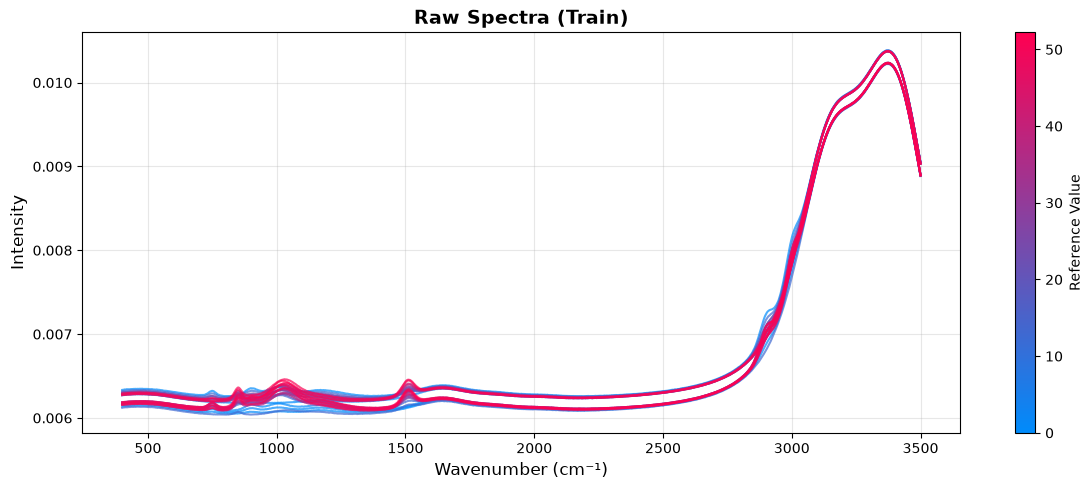

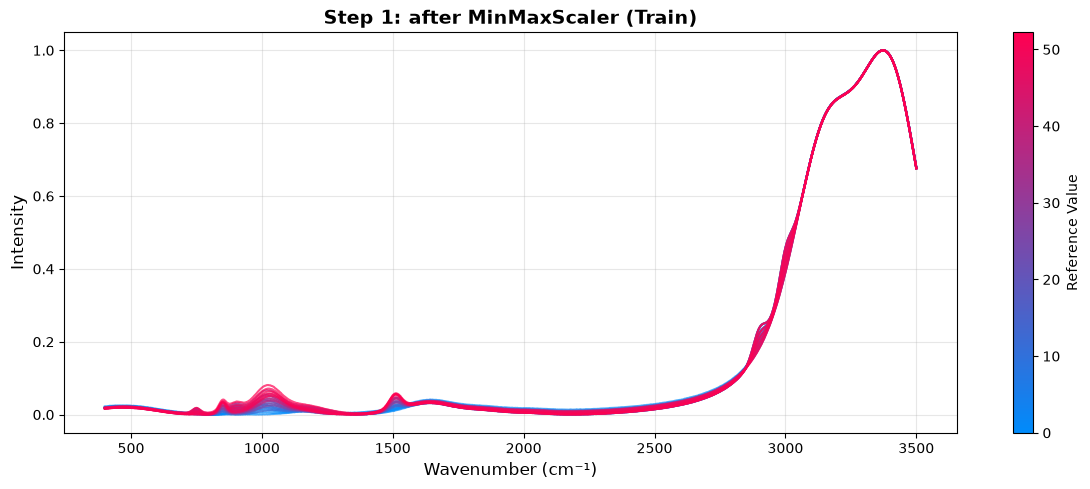

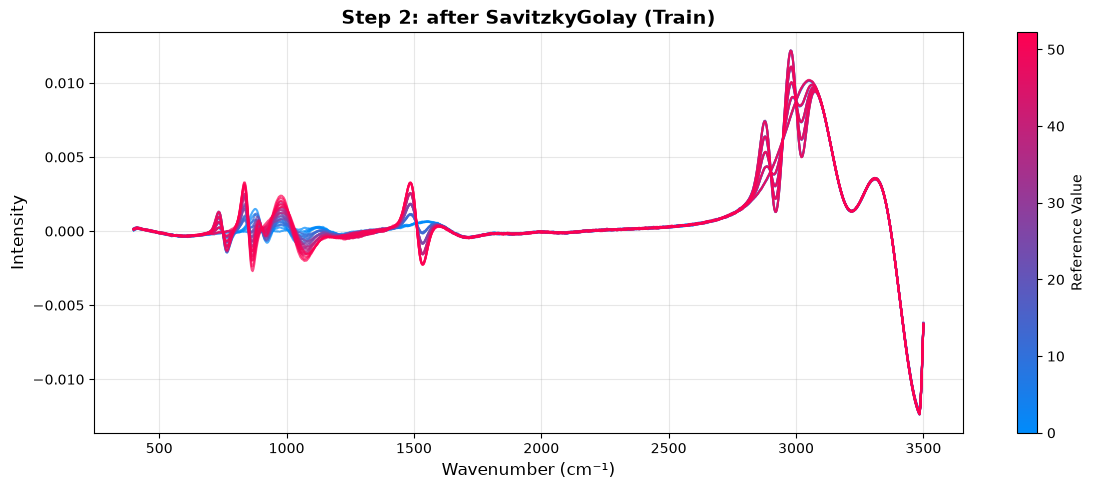

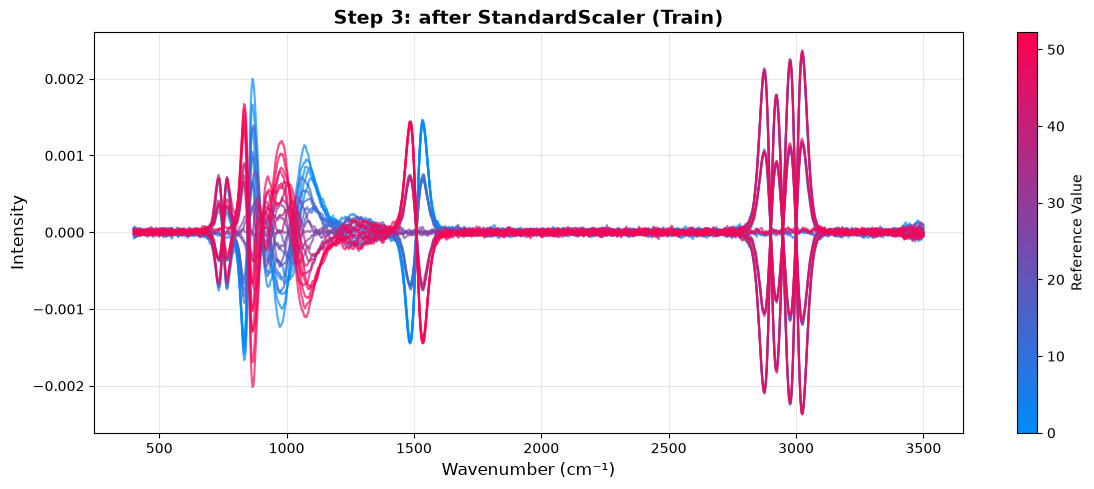

In [4]:
from chemotools.inspector import PreprocessingInspector

# Walk through each preprocessing step and plot its effect on the spectra
inspector = PreprocessingInspector(pipe, X_train=X, y_train=y, x_axis=x_axis)
inspector.inspect();


#### **D. Train / test split with Astartes**
A random split can leave gaps in the calibration space or, worse, put nearly identical samples in both sets — leading to overoptimistic error estimates. Astartes provides the Kennard-Stone sampler, which maximises the spectral coverage of the training set and ensures the test set probes genuinely different regions of the data space.

**See also:** [Sampling with Astartes](https://chemotools.org/explore/astartes.html)

In [24]:
from astartes import train_test_split

# Kennard-Stone split: maximises spectral space coverage in the training set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.75,
    sampler="kennard_stone",
    random_state=21,
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Training set: 18 samples
Test set:     7 samples


/Users/paucablop/git/home/chemotools-tutorials/.venv/lib/python3.13/site-packages/astartes/main.py:325: ImperfectSplittingWarning: Actual train/test split differs from requested size. Requested train size of 0.75, got 0.72. Requested test size of 0.25, got 0.28. 
  warn(


#### **E. Cross-validation to find the optimal number of components**
Too few PLS components and the model underfits; too many and it starts to overfit noise. We use `GridSearchCV` with 5-fold cross-validation to evaluate models with 1–10 components on the training set and select the one with the lowest RMSECV.

**See also:** [Optimise your model](https://chemotools.org/explore/optimize.html) · [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

In [25]:
from sklearn.model_selection import GridSearchCV, KFold

# Fresh pipeline for cross-validation (GridSearchCV will refit it internally)
pipe_cv = make_pipeline(
    MinMaxScaler(),
    SavitzkyGolay(window_length=11, polyorder=2, deriv=1),
    StandardScaler(with_std=False),
    PLSRegression(n_components=1, scale=False),
)

# Search over 1–10 PLS components using 5-fold CV on the training set
param_grid = {"plsregression__n_components": list(range(1, 11))}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe_cv,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

n_opt = grid.best_params_["plsregression__n_components"]
print(f"Optimal n_components: {n_opt}")
print(f"Best RMSECV:          {-grid.best_score_:.4f}")


Optimal n_components: 2
Best RMSECV:          0.6308


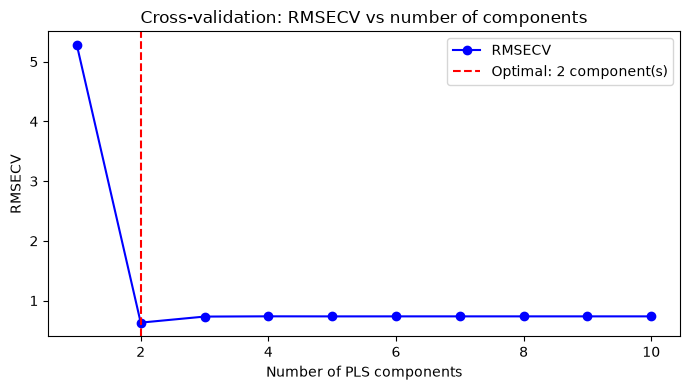

In [26]:
# Plot RMSECV as a function of the number of components
n_components = param_grid["plsregression__n_components"]
rmsecv = -grid.cv_results_["mean_test_score"]

plt.figure(figsize=(7, 4))
plt.plot(n_components, rmsecv, "o-", color="blue", label="RMSECV")
plt.axvline(n_opt, color="red", linestyle="--", label=f"Optimal: {n_opt} component(s)")
plt.xlabel("Number of PLS components")
plt.ylabel("RMSECV")
plt.title("Cross-validation: RMSECV vs number of components")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
# Select the best model
pipe_final = grid.best_estimator_

#### **F. Final model and inspection**
The `PLSRegressionInspector` generates a complete diagnostic suite — scores, loadings, regression coefficients, predicted vs actual, and outlier detection — in a single call.

**See also:** [Inspecting your models](https://chemotools.org/explore/inspector_fundamentals.html)

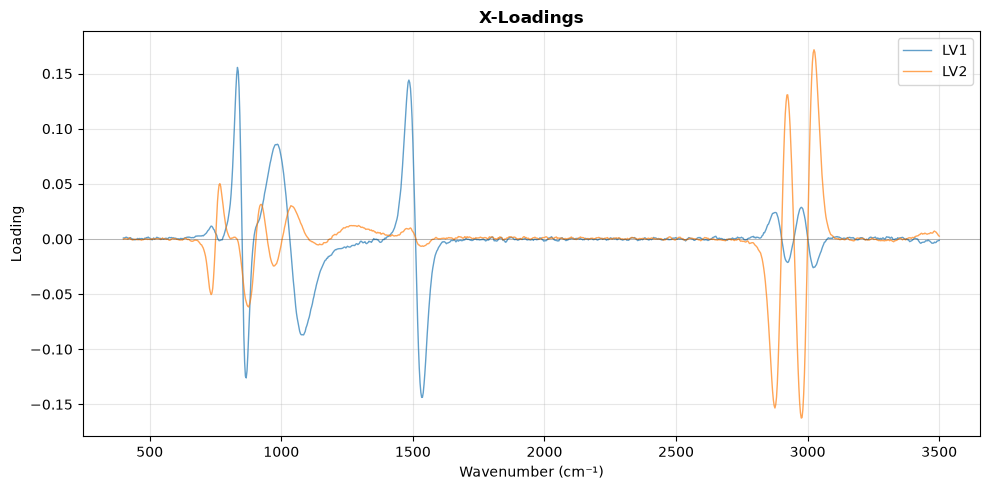

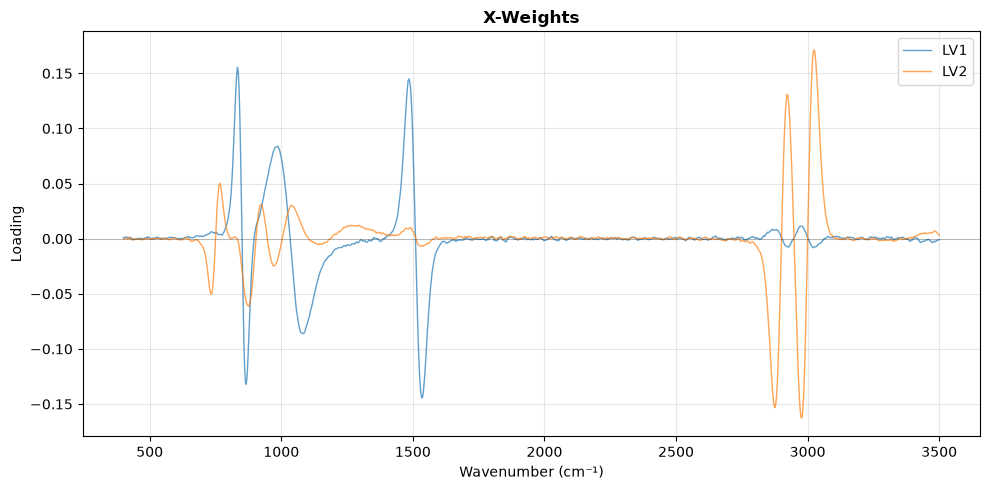

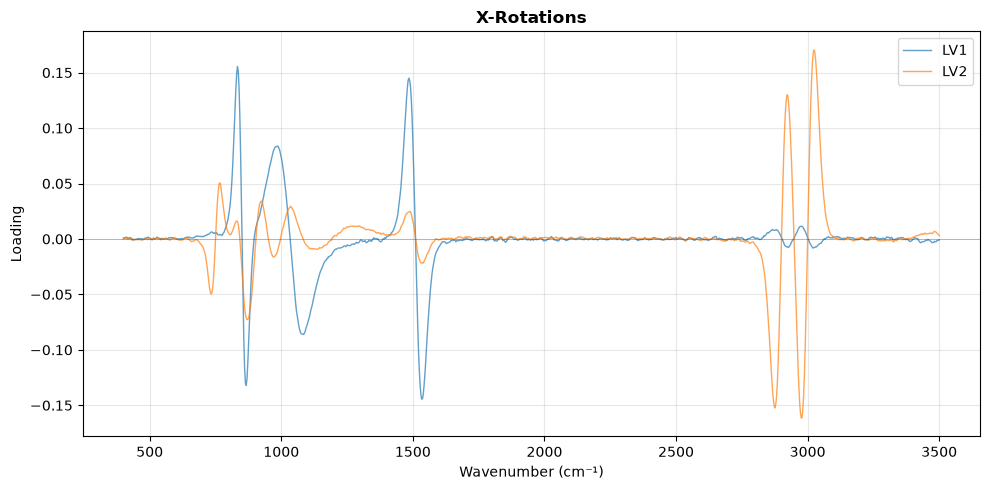

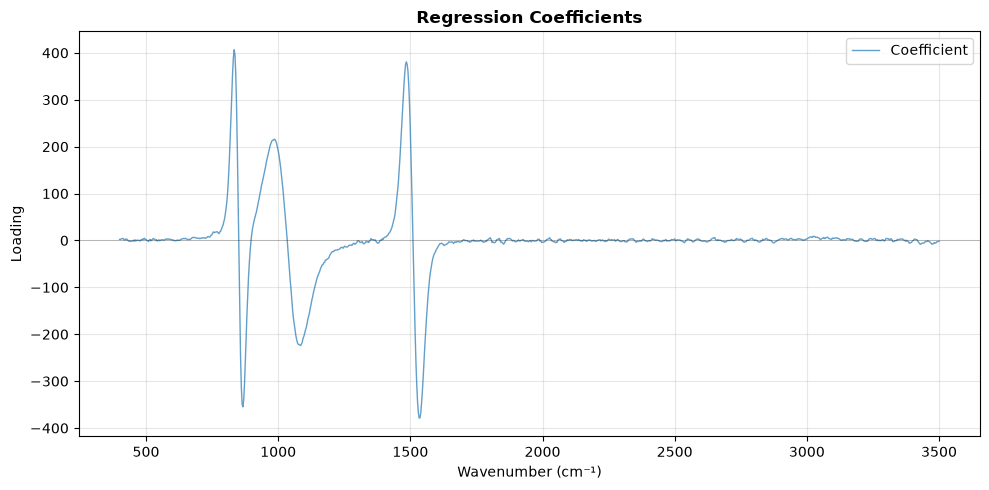

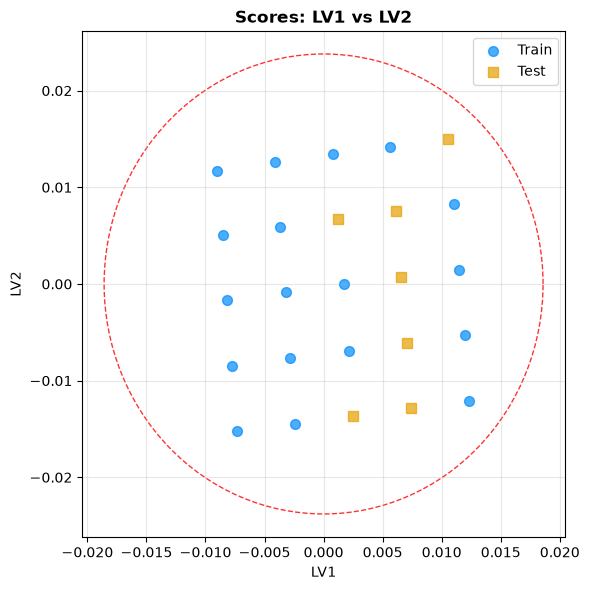

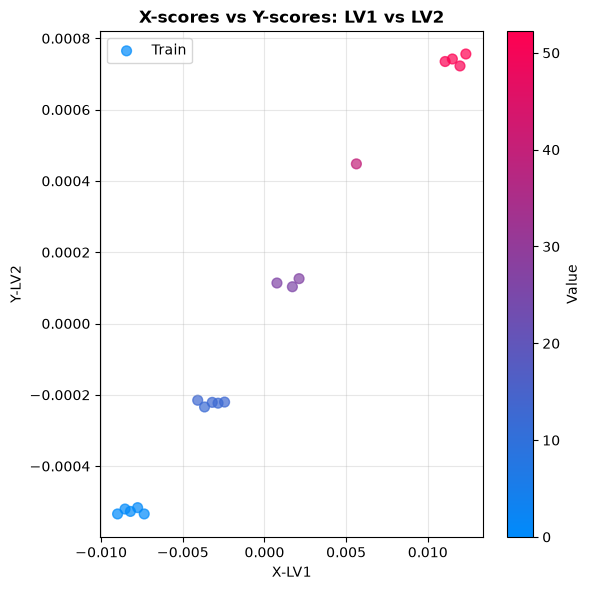

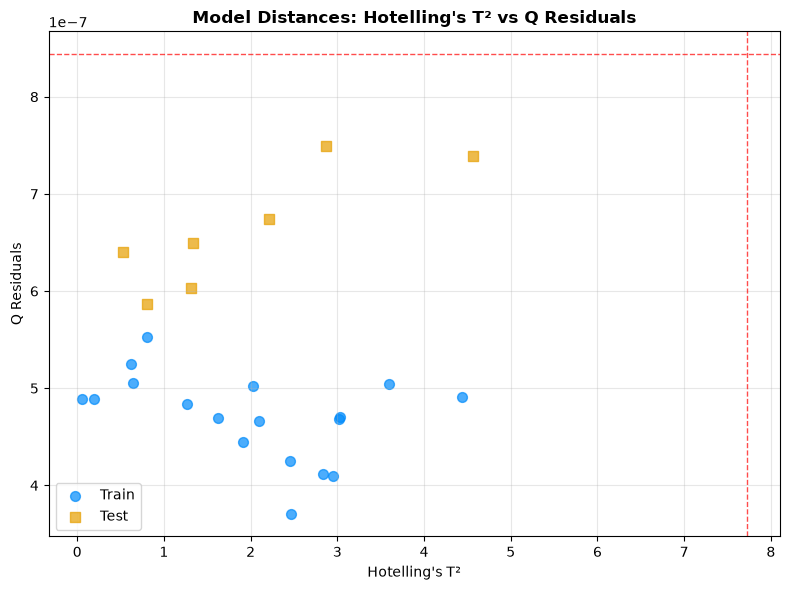

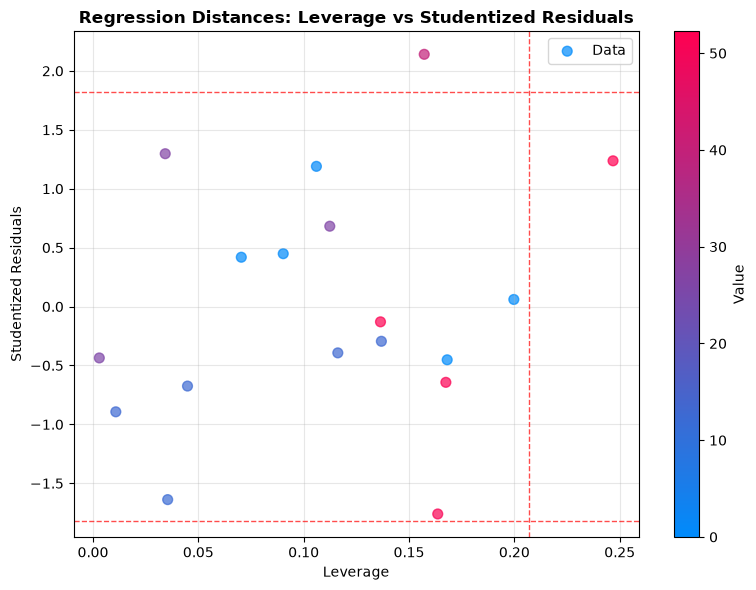

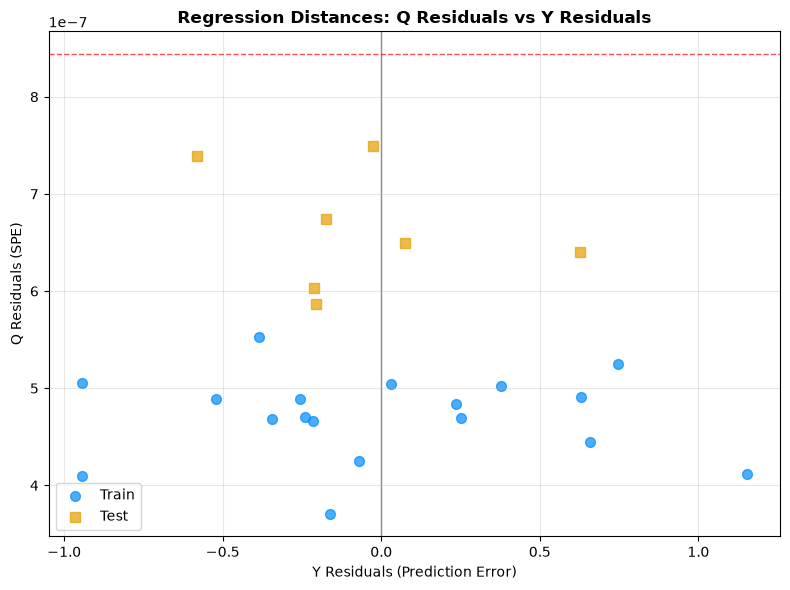

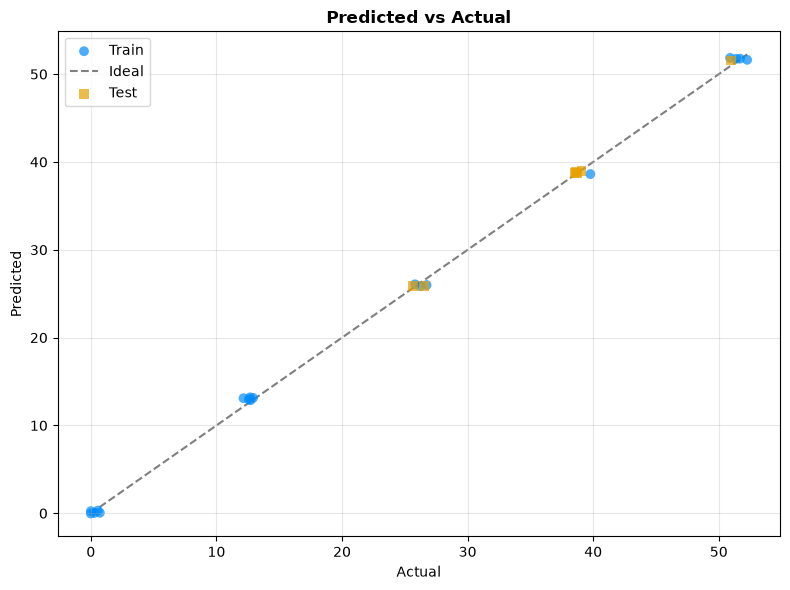

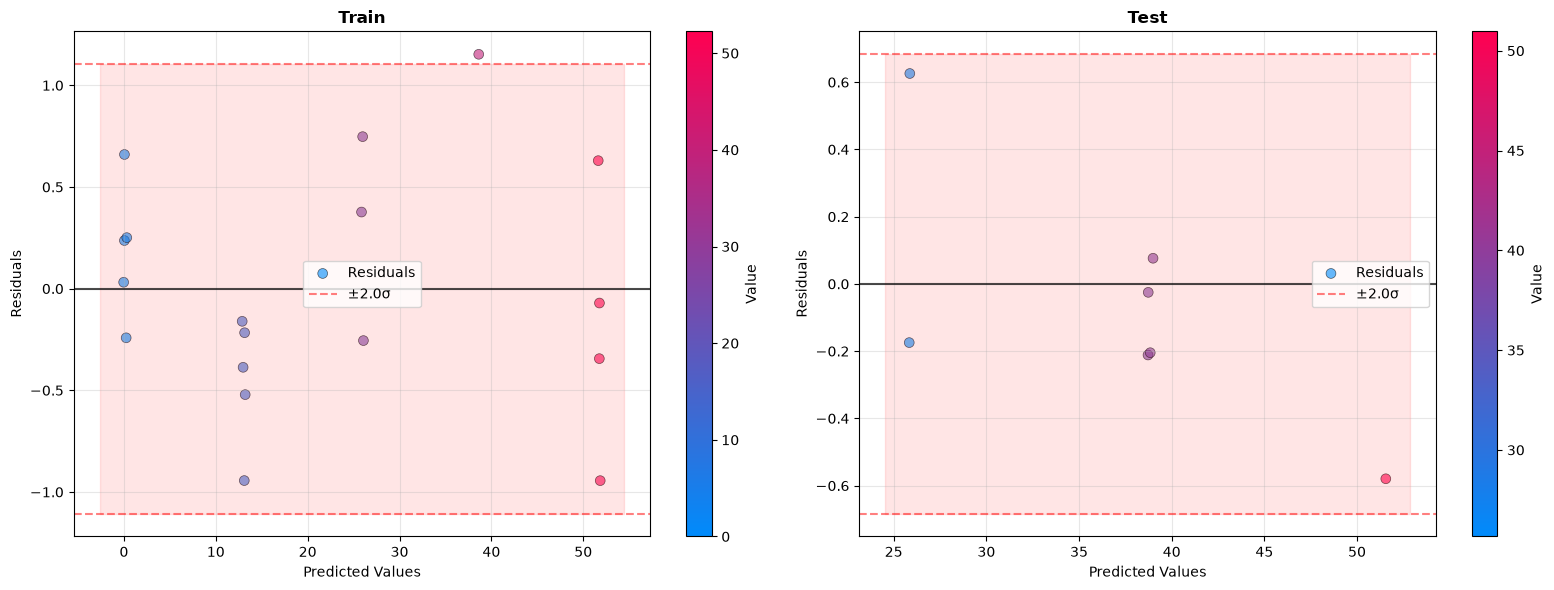

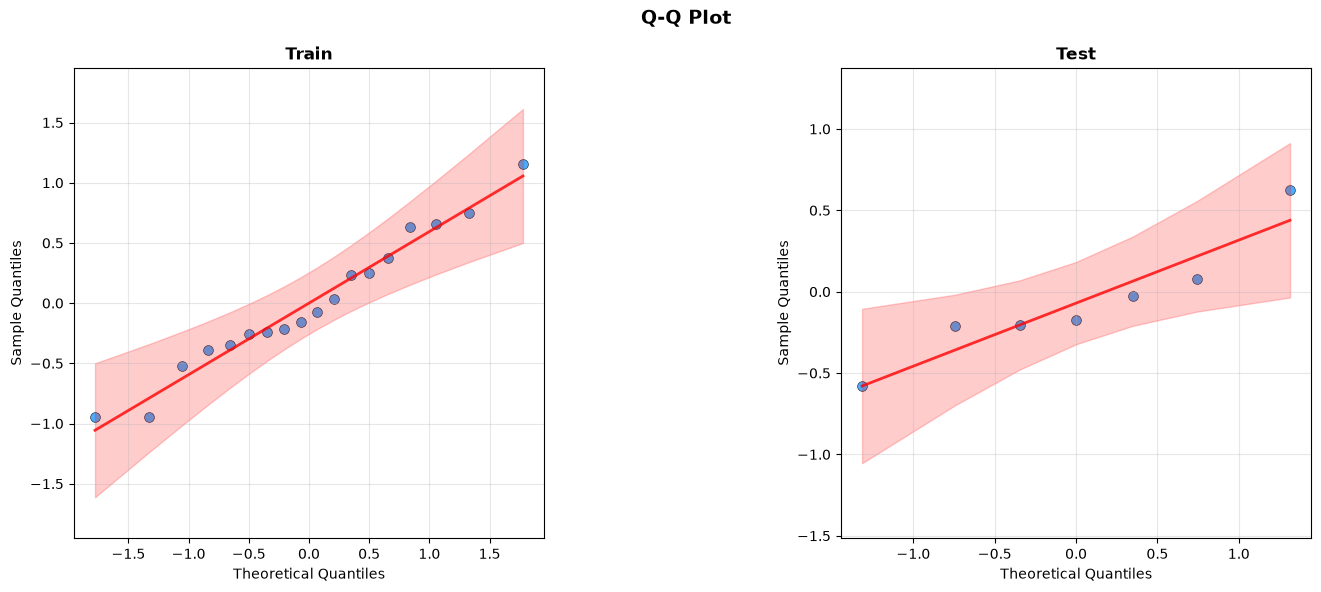

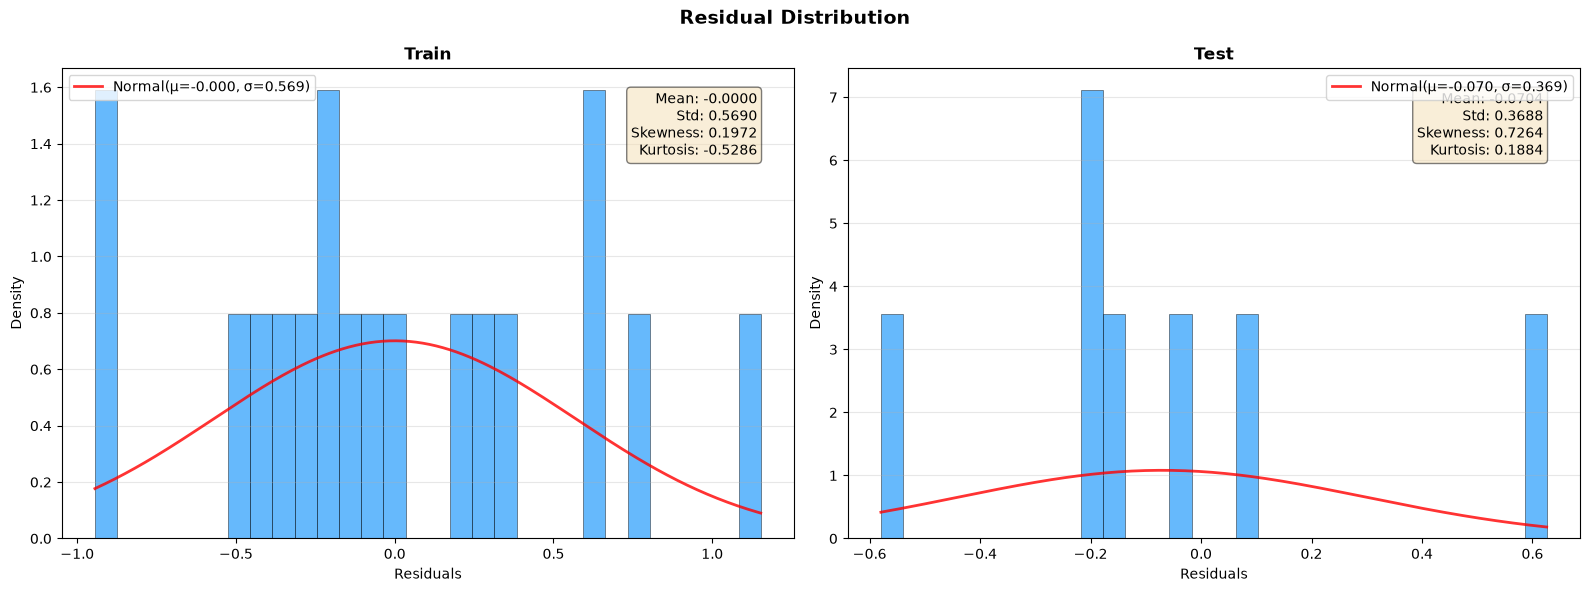

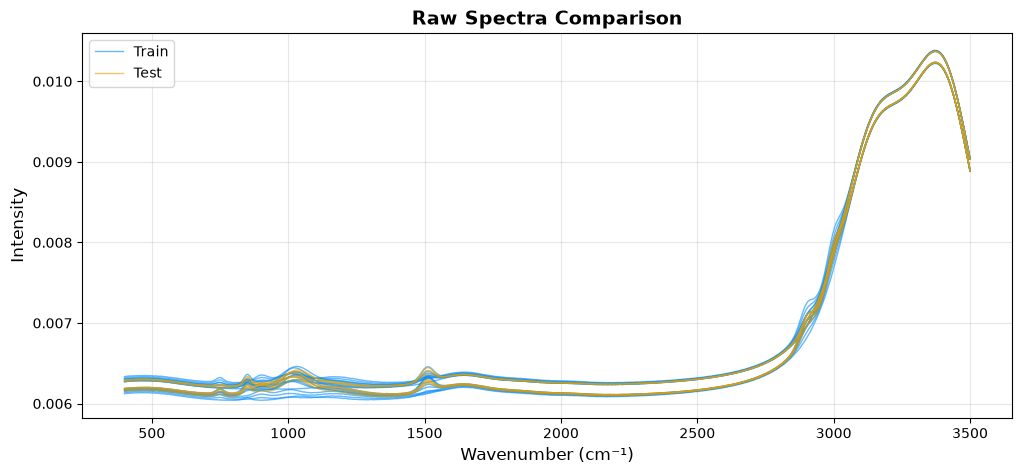

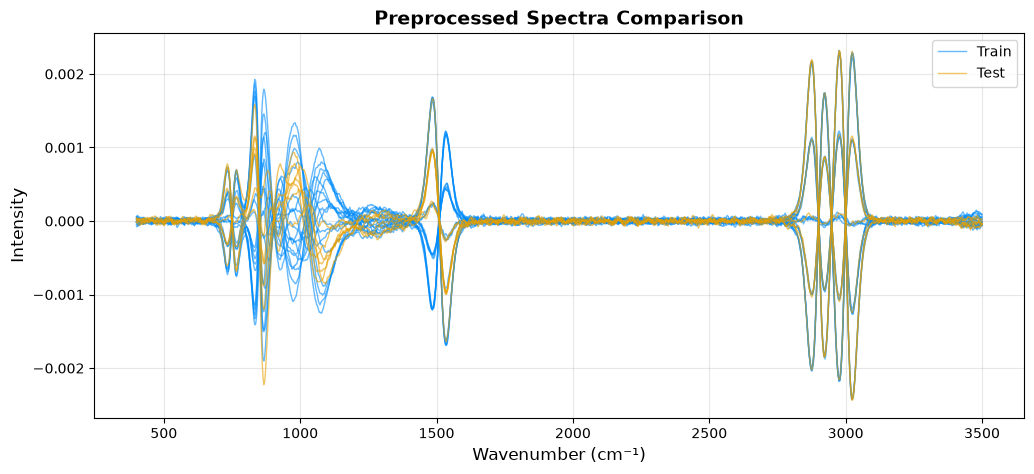

In [27]:
from chemotools.inspector import PLSRegressionInspector

# Full diagnostic suite: scores, loadings, coefficients, predicted vs actual, outliers
inspector = PLSRegressionInspector(
    pipe_final,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    x_axis=x_axis,
)
inspector.inspect(dataset=["train", "test"]);


#### **G. Persist the model**
Once we are happy with the model we save the entire pipeline — preprocessing steps included — to disk so it can be reloaded and used for prediction without retraining. We use `joblib`, which is the recommended approach for scikit-learn pipelines that contain NumPy arrays.

**See also:** [Persisting your models](https://chemotools.org/explore/persist.html)

In [28]:
from joblib import dump, load

# Save the full pipeline (preprocessing + PLS model) to disk
dump(pipe_final, "local/tutorial_1_pls_model.joblib")
print("Model saved to local/tutorial_1_pls_model.joblib")


Model saved to local/tutorial_1_pls_model.joblib
